# Sensor Correlation Analysis — iTransformer 정당화 근거 수집

## 목적
C-MAPSS / N-CMAPSS 의 센서 간 상호작용이 얼마나 강한지 정량 분석하여,
**iTransformer (variate tokenization, cross-channel attention) 가 정당화되는지** 판단한다.

## 분석 항목

1. **Static correlation**: 모든 시점에 걸친 Pearson / Spearman correlation matrix
2. **Dynamic correlation**: 운전 사이클 진행에 따른 correlation 변화 (initial vs late cycle)
3. **Cross-channel mutual information**: linear correlation 외 비선형 의존성
4. **Sensor importance vs RUL**: 각 센서가 RUL 과 어느 정도 관련 있는지
5. **Channel-independent test**: DLinear 가 채널 독립적이라 못 잡는 패턴이 있는지

## 판정 기준

iTransformer 도입이 정당화되는 조건:
- 평균 |corr| > 0.5 (강한 cross-channel dependency)
- correlation 패턴이 시점에 따라 크게 변화 (dynamic interaction)
- Mutual Information / linear corr 비율이 높음 (비선형 의존성)
- 채널 페어별로 RUL 예측 기여도가 크게 다름

In [1]:
import sys
import os
from pathlib import Path

# 프로젝트 루트를 sys.path 에 추가
ROOT = Path.cwd().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr
from sklearn.feature_selection import mutual_info_regression

plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_style('whitegrid')

from models_core import data_pipeline as dp
from models_core import config

## 1. 데이터 로드 — C-MAPSS FD001 ~ FD004 모두 비교

각 sub-dataset 의 sensor correlation 패턴을 비교한다.
특히 FD001(쉬움, 1 op condition) vs FD004(어려움, 6 op conditions) 의 차이가 중요.

In [2]:
def load_cmapss_raw(subset: str):
    """C-MAPSS 원본 데이터프레임 로드 (window 변환 전)."""
    root = config.DATASET_PATHS['cmapss']
    train_fp = root / f'train_{subset}.txt'
    df = pd.read_csv(train_fp, sep=r'\s+', header=None, names=dp.CMAPSS_COLS)
    return df

subsets = ['FD001', 'FD002', 'FD003', 'FD004']
raw_dfs = {}
for s in subsets:
    try:
        raw_dfs[s] = load_cmapss_raw(s)
        print(f'{s}: {raw_dfs[s].shape}, engines: {raw_dfs[s]["unit"].nunique()}')
    except FileNotFoundError as e:
        print(f'{s}: SKIP - {e}')

feature_cols = dp.CMAPSS_USE_SENSORS
print(f'\n사용 센서 ({len(feature_cols)}): {feature_cols}')

FD001: (20631, 26), engines: 100
FD002: (53759, 26), engines: 260
FD003: (24720, 26), engines: 100
FD004: (61249, 26), engines: 249

사용 센서 (14): ['s2', 's3', 's4', 's7', 's8', 's9', 's11', 's12', 's13', 's14', 's15', 's17', 's20', 's21']


## 2. Static Correlation Matrix (Pearson)

전체 시점·전체 엔진에 걸친 Pearson correlation. iTransformer 의 variate tokenization 가정 검증.

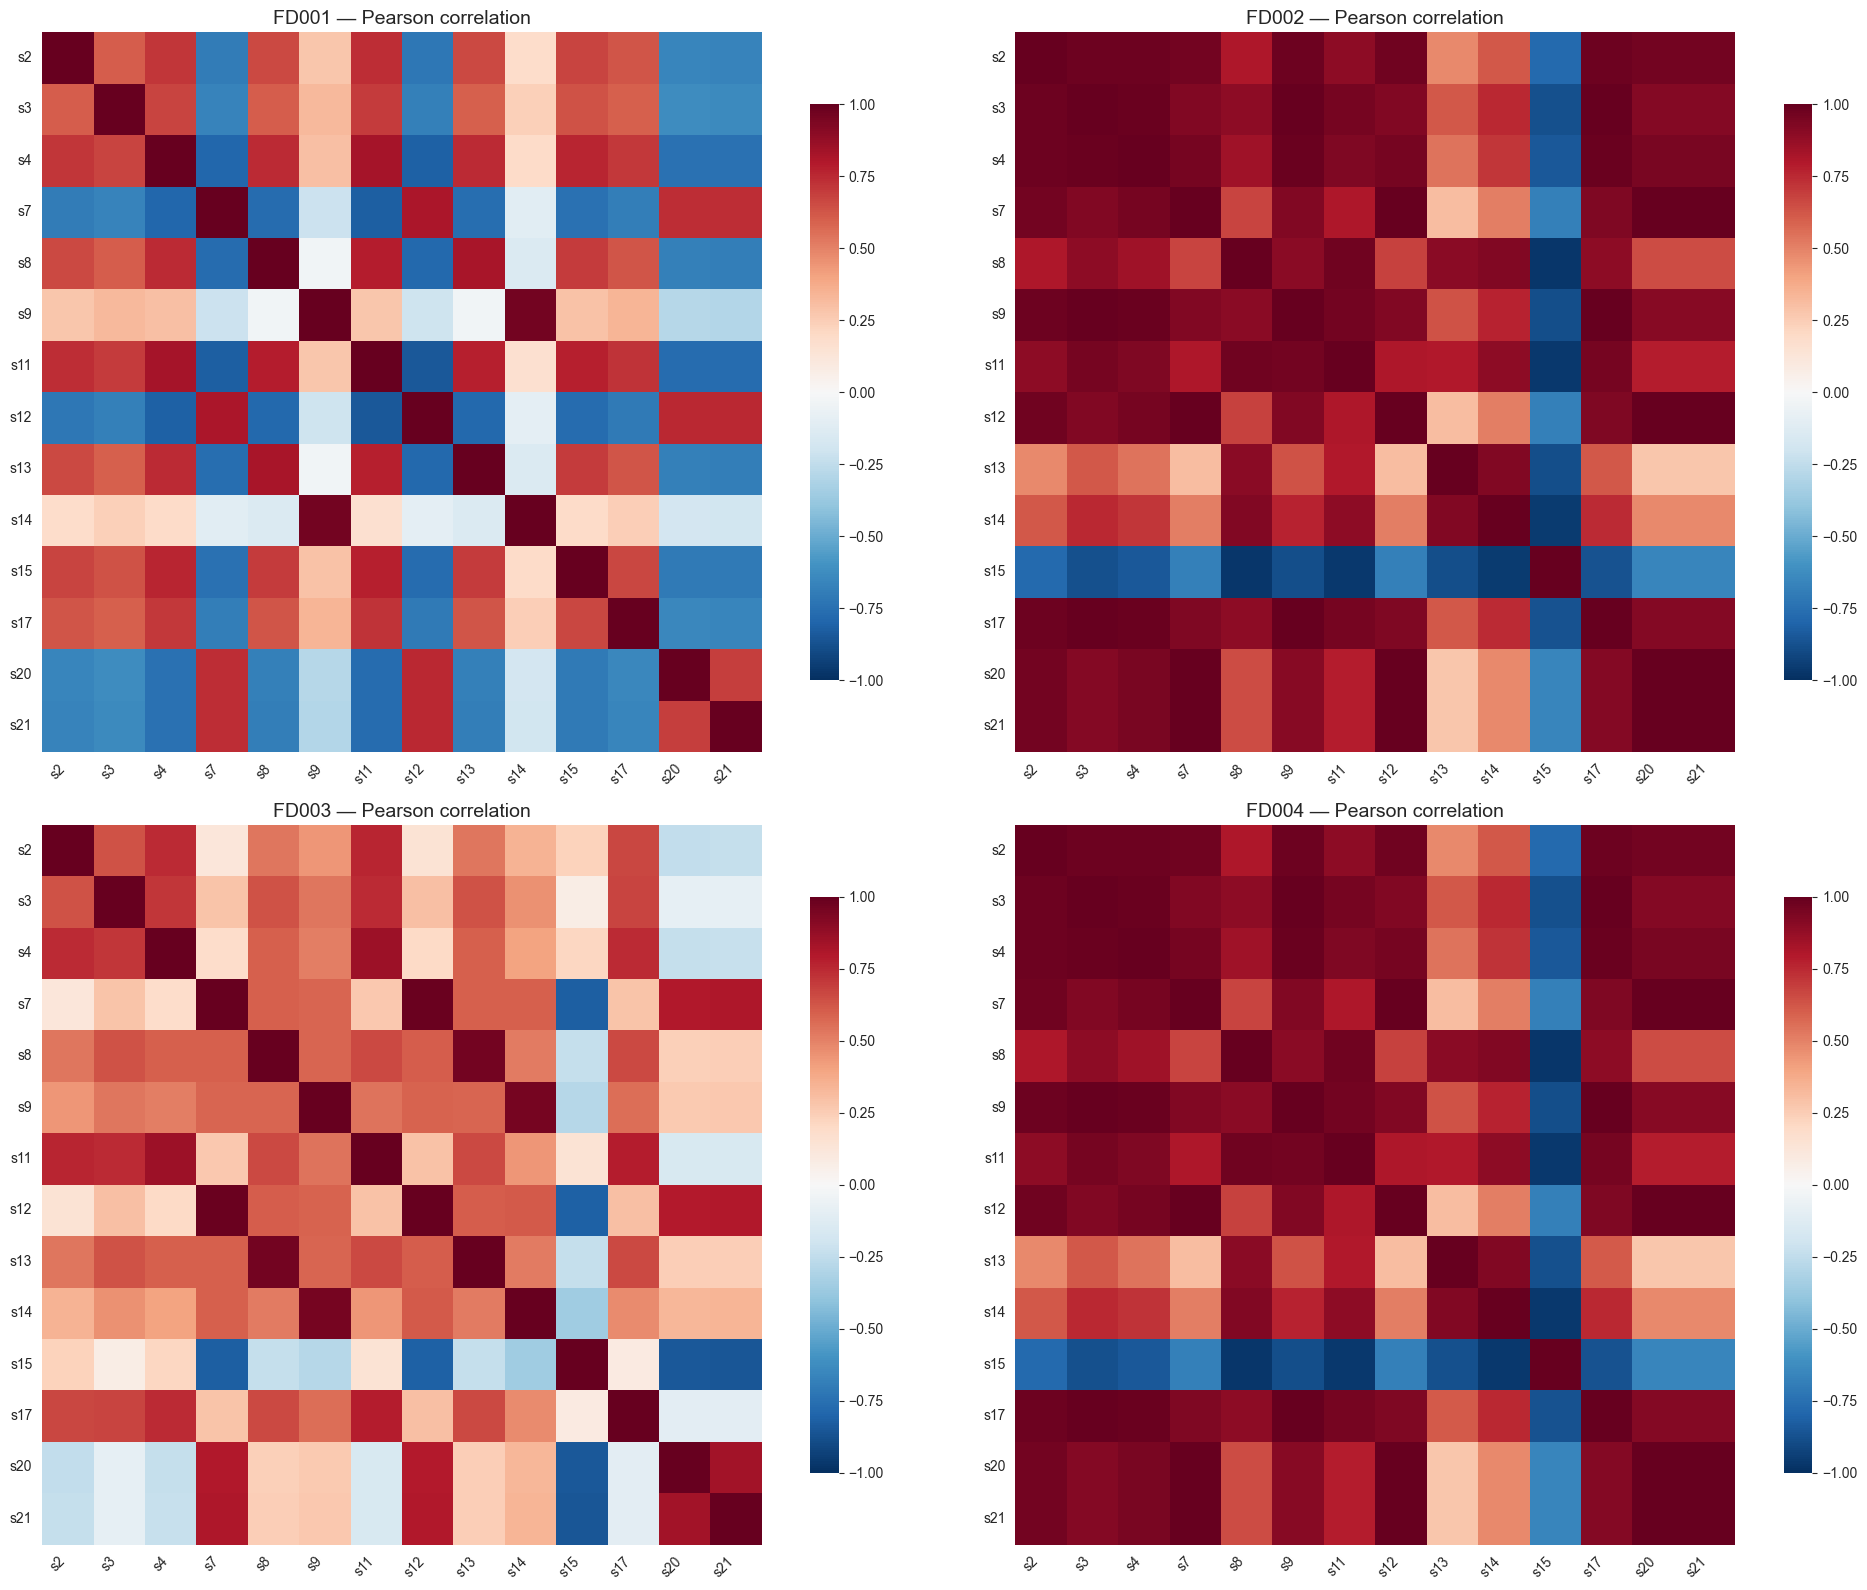

=== 평균 |corr| (대각 제외) ===
FD001: 0.5834
FD002: 0.8278
FD003: 0.4796
FD004: 0.8279


In [3]:
fig, axes = plt.subplots(2, 2, figsize=(20, 16))
for ax, s in zip(axes.flat, subsets):
    if s not in raw_dfs:
        continue
    corr = raw_dfs[s][feature_cols].corr(method='pearson')
    sns.heatmap(corr, ax=ax, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
                annot=False, square=True, cbar_kws={'shrink': 0.8})
    ax.set_title(f'{s} — Pearson correlation', fontsize=14)
    ax.set_xticklabels(feature_cols, rotation=45, ha='right')
    ax.set_yticklabels(feature_cols, rotation=0)
plt.tight_layout()
plt.show()

# 평균 |corr| 보고
print('=== 평균 |corr| (대각 제외) ===')
for s in subsets:
    if s not in raw_dfs:
        continue
    corr = raw_dfs[s][feature_cols].corr().abs()
    np.fill_diagonal(corr.values, 0)
    mean_abs = corr.values[corr.values > 0].mean()
    print(f'{s}: {mean_abs:.4f}')

### 해석 가이드

- 평균 |corr| > 0.5: 강한 cross-channel dependency → iTransformer 우위 기대
- 0.3 ~ 0.5: 중간 → DLinear 도 일정 수준 가능
- < 0.3: 약함 → channel-independent (PatchTST) 도 충분할 수 있음

## 3. Dynamic Correlation — 운전 사이클 초기 vs 후기

고장 진행에 따라 센서 간 관계가 변하는지. 강하게 변하면 시변(時變) attention 이 의미.
각 엔진의 RUL 25% 이하 (degradation 임박) 구간과 RUL 75% 이상 (초기) 구간 비교.

In [4]:
def split_by_rul_quartile(df: pd.DataFrame):
    """각 엔진의 max cycle 을 사용해 RUL 정규화 후 25% / 75% 분할."""
    df = df.copy()
    max_cycle = df.groupby('unit')['cycle'].transform('max')
    df['rul_pct'] = (max_cycle - df['cycle']) / max_cycle
    early = df[df['rul_pct'] >= 0.75]  # 운전 초기 (RUL 충분)
    late  = df[df['rul_pct'] <= 0.25]  # 운전 후기 (degradation 임박)
    return early, late

print('=== 평균 |corr| 변화: early vs late ===')
for s in subsets:
    if s not in raw_dfs:
        continue
    early, late = split_by_rul_quartile(raw_dfs[s])
    corr_e = early[feature_cols].corr().abs()
    corr_l = late[feature_cols].corr().abs()
    np.fill_diagonal(corr_e.values, 0)
    np.fill_diagonal(corr_l.values, 0)
    mean_e = corr_e.values[corr_e.values > 0].mean()
    mean_l = corr_l.values[corr_l.values > 0].mean()
    diff = corr_l - corr_e
    max_change = float(np.abs(diff.values).max())
    print(f'{s}: early={mean_e:.4f}, late={mean_l:.4f}, '
          f'max_pair_change={max_change:.4f}')

=== 평균 |corr| 변화: early vs late ===
FD001: early=0.4635, late=0.4476, max_pair_change=0.4483
FD002: early=0.8282, late=0.8250, max_pair_change=0.0366
FD003: early=0.3530, late=0.4394, max_pair_change=0.4501
FD004: early=0.8300, late=0.8246, max_pair_change=0.0273


## 4. Sensor ↔ RUL Mutual Information (비선형 의존성)

각 센서가 RUL 과 얼마나 강한 비선형 관계를 갖는지.
Pearson 보다 더 일반적인 정보량 metric.

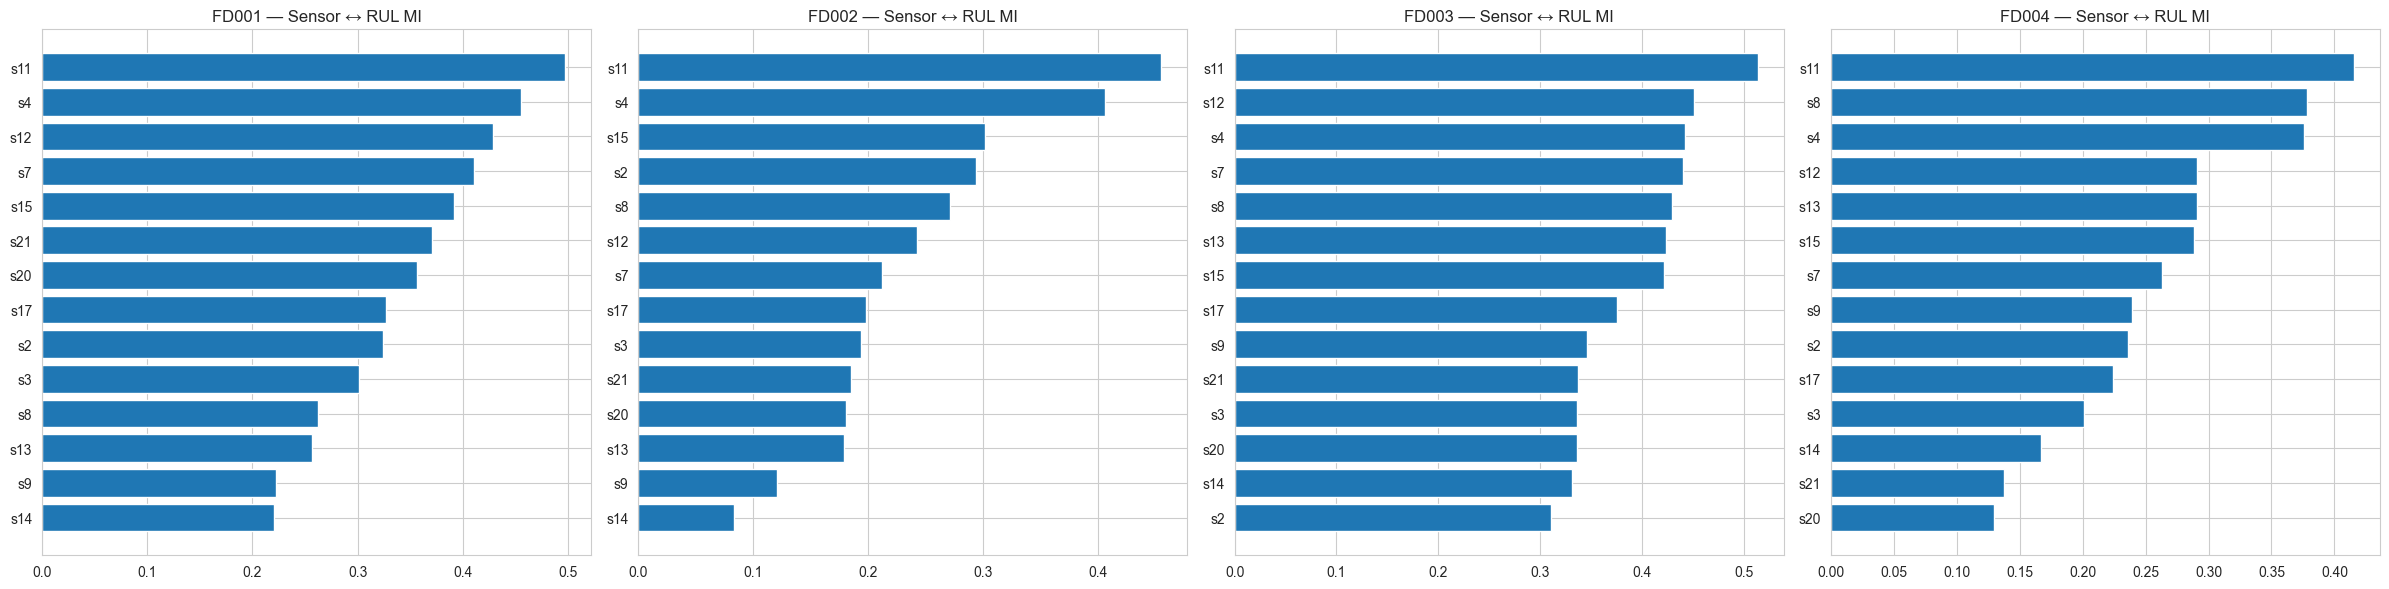

=== Total MI (sum across sensors) ===
FD001: total=4.825, sensors with MI>0.1: 14/14
FD002: total=3.324, sensors with MI>0.1: 13/14
FD003: total=5.497, sensors with MI>0.1: 14/14
FD004: total=3.637, sensors with MI>0.1: 14/14


In [5]:
from models_core.config import LSTM_CFG
RUL_CLIP = LSTM_CFG['rul_clip']

def add_rul(df: pd.DataFrame, rul_clip: float = RUL_CLIP):
    df = df.copy()
    max_cycle = df.groupby('unit')['cycle'].transform('max')
    df['RUL'] = np.minimum(rul_clip, max_cycle - df['cycle'])
    return df

fig, axes = plt.subplots(1, len(raw_dfs), figsize=(6 * len(raw_dfs), 6))
if len(raw_dfs) == 1:
    axes = [axes]

mi_results = {}
for ax, s in zip(axes, subsets):
    if s not in raw_dfs:
        continue
    df = add_rul(raw_dfs[s])
    # 큰 데이터셋은 sampling
    df_s = df.sample(min(20000, len(df)), random_state=42)
    X = df_s[feature_cols].values
    y = df_s['RUL'].values
    mi = mutual_info_regression(X, y, random_state=42)
    mi_results[s] = dict(zip(feature_cols, mi))
    order = np.argsort(mi)[::-1]
    ax.barh([feature_cols[i] for i in order], mi[order])
    ax.set_title(f'{s} — Sensor ↔ RUL MI')
    ax.invert_yaxis()
plt.tight_layout()
plt.show()

# MI 합계 비교
print('=== Total MI (sum across sensors) ===')
for s, mi_dict in mi_results.items():
    total = sum(mi_dict.values())
    n_strong = sum(1 for v in mi_dict.values() if v > 0.1)
    print(f'{s}: total={total:.3f}, sensors with MI>0.1: {n_strong}/{len(mi_dict)}')

## 5. 종합 판정 — iTransformer 정당화 여부

위 4개 분석 결과를 종합.

In [6]:
verdict_rows = []
for s in subsets:
    if s not in raw_dfs:
        continue
    df = raw_dfs[s]
    # 1) static corr
    corr = df[feature_cols].corr().abs()
    np.fill_diagonal(corr.values, 0)
    mean_abs_corr = corr.values[corr.values > 0].mean()
    
    # 2) dynamic corr change
    early, late = split_by_rul_quartile(df)
    corr_e = early[feature_cols].corr().abs()
    corr_l = late[feature_cols].corr().abs()
    np.fill_diagonal(corr_e.values, 0)
    np.fill_diagonal(corr_l.values, 0)
    dyn_change = float(np.abs(corr_l.values - corr_e.values).mean())

    # 3) MI total
    mi_total = sum(mi_results.get(s, {}).values()) if mi_results else 0.0
    
    # 판정
    score = 0
    if mean_abs_corr > 0.5: score += 2
    elif mean_abs_corr > 0.3: score += 1
    if dyn_change > 0.1: score += 2
    elif dyn_change > 0.05: score += 1
    if mi_total > 5.0: score += 2
    elif mi_total > 2.0: score += 1
    
    if score >= 5:
        verdict = '✅ iTransformer 강하게 정당화'
    elif score >= 3:
        verdict = '🟡 iTransformer 시도 권장'
    else:
        verdict = '🔴 단순 모델로 충분할 수 있음'
    
    verdict_rows.append({
        'subset': s,
        'mean_|corr|': round(mean_abs_corr, 4),
        'dyn_change': round(dyn_change, 4),
        'MI_total': round(mi_total, 4),
        'score': score,
        'verdict': verdict,
    })

verdict_df = pd.DataFrame(verdict_rows)
print(verdict_df.to_string(index=False))

subset  mean_|corr|  dyn_change  MI_total  score                verdict
 FD001       0.5834      0.1153    4.8249      5 ✅ iTransformer 강하게 정당화
 FD002       0.8278      0.0052    3.3243      3   🟡 iTransformer 시도 권장
 FD003       0.4796      0.1476    5.4974      5 ✅ iTransformer 강하게 정당화
 FD004       0.8279      0.0058    3.6373      3   🟡 iTransformer 시도 권장


## 6. 후속 결론 작성 가이드

결과 표를 기반으로 다음 형식으로 결론 정리:

1. 어느 FD subset 에서 cross-channel dependency 가 가장 강한가?
2. iTransformer 가 어느 subset 에서 가장 큰 이득을 보일 것으로 예측?
3. DLinear (channel-independent) 가 어느 subset 에서 충분히 강할 것으로 예측?
4. dynamic correlation 변화가 큰 subset 에서는 attention 기반 시변 모델 (TFT 등) 도 검토 가치